## __Data Science: Capstone Part 2: Lightning Talk 2__

# Motor Fault Detection Using Motor Current Signature Analysis (MCSA)

**Data Source:**[Motor Current and Vibration Monitoring Dataset for various Faults in an E-motor-driven Centrifugal Pump](https://doi.org/10.4121/2b61183e-c14f-4131-829b-cc4822c369d0)  

## 1- Problem Statement

Induction motors account for nearly 70% of industrial electricity consumption worldwide ([Eichhammer, 2012](https://www.researchgate.net/publication/265395773_Energy_efficiency_in_electric_motor_systems_Technology_saving_potentials_and_policy_options_for_developing_countries)), making their reliability critical to manufacturing, processing, and utilities sectors. When a motor fails unexpectedly, the cost of downtime frequently exceeds the cost of the motor itself, leading to significant production losses and maintenance expenses.

Among the most common failure modes, stator-related faults account for 36–38% of failures and rotor-related faults account for 10% ([Maraaba, 2018](https://www.mdpi.com/1996-1073/11/3/653)). The two fault types studied in this project — Broken Rotor Bar (BRB) and Stator Winding Fault (SWF) — together represent nearly half of all induction motor failures in industrial settings.

Early detection of these faults before they escalate to full motor failure is the goal of condition monitoring. Several approaches exist: vibration analysis is effective but requires dedicated accelerometers mounted on the motor casing, adding hardware cost and installation complexity. Thermal imaging can detect winding hotspots but requires line-of-sight access and is unsuitable for continuous online monitoring. Motor Current Signature Analysis (MCSA) avoids both limitations — it is a fully non-invasive technique that detects fault-specific frequency signatures directly from stator current measurements, using existing current sensors with no additional hardware.

The limitation of conventional MCSA systems, however, is that they rely on hand-crafted, threshold-based rules — for example, checking whether a sideband ratio at `f ± 2sf` exceeds a fixed threshold. These rules require domain expertise to configure, are sensitive to changes in operating speed and load, and do not generalise across different motor types without manual re-tuning.

**This project asks:** Can a machine learning classifier trained on engineered time-domain and FFT-based features from three-phase motor current signals match or outperform the existing rule-based MCSA fault detection system developed in a prior senior thesis (Bahrain Polytechnic, 2024) — and which feature extraction approach (time-domain, FFT, wavelet, or hybrid) provides the strongest classification performance?

**Target variable:** `condition` — a three-class label: `healthy`, `brb` (Broken Rotor Bar), `swf` (Stator Winding Fault).

**Success metrics:** Weighted F1-score ≥ 0.90 on a held-out test set; per-class precision and recall ≥ 0.85 for each fault type.

## 2- Objectives

1. Do raw signal amplitude values contain any useful information for identifying fault conditions, or do we need to extract frequency-domain features first?
2. Which signal statistics — such as RMS and kurtosis — show the clearest difference between healthy, BRB, and SWF motors?
3. Are the five measurement replicates per phase consistent with each other, or do they introduce unwanted variability into the dataset?
4. Does the motor's operating speed affect how a fault appears in the signal, and does this need to be accounted for in the model?
5. Which feature extraction approach — time-domain, FFT, wavelet, or a combination — gives the best classification accuracy?
6. Can one model handle all three operating speeds, or does each speed need its own model?

# Data Inspection

## 1- Data Dictionary

The master dataset was compiled from raw per-phase, per-measurement CSV files from the Bruinsma et al. (2024) experimental dataset (Motor 2 only). Each row represents one time-domain current sample at a specific operating point.

| Column | Type | Description |
|--------|------|-------------|
| `time` | float64 | Timestamp of the sample in seconds, relative to the start of each recording |
| `A_m1` | float64 | Phase A current amplitude (Amperes) — measurement replicate 1 |
| `A_m2` | float64 | Phase A current amplitude (Amperes) — measurement replicate 2 |
| `A_m3` | float64 | Phase A current amplitude (Amperes) — measurement replicate 3 |
| `A_m4` | float64 | Phase A current amplitude (Amperes) — measurement replicate 4 |
| `A_m5` | float64 | Phase A current amplitude (Amperes) — measurement replicate 5 |
| `B_m1` | float64 | Phase B current amplitude (Amperes) — measurement replicate 1 |
| `B_m2` | float64 | Phase B current amplitude (Amperes) — measurement replicate 2 |
| `B_m3` | float64 | Phase B current amplitude (Amperes) — measurement replicate 3 |
| `B_m4` | float64 | Phase B current amplitude (Amperes) — measurement replicate 4 |
| `B_m5` | float64 | Phase B current amplitude (Amperes) — measurement replicate 5 |
| `C_m1` | float64 | Phase C current amplitude (Amperes) — measurement replicate 1 |
| `C_m2` | float64 | Phase C current amplitude (Amperes) — measurement replicate 2 |
| `C_m3` | float64 | Phase C current amplitude (Amperes) — measurement replicate 3 |
| `C_m4` | float64 | Phase C current amplitude (Amperes) — measurement replicate 4 |
| `C_m5` | float64 | Phase C current amplitude (Amperes) — measurement replicate 5 |
| `speed` | int64 | Motor load speed as a percentage of rated speed: `50`, `75`, or `100` |
| `condition` | object | **Target variable.** Motor fault condition: `healthy`, `brb` (Broken Rotor Bar), `swf` (Stator Winding Fault) |

**Notes:**
- Signal columns follow the naming pattern `{phase}_{measurement}` where phase {A, B, C} and measurement {m1, m2, m3, m4, m5}.
- Each measurement replicate is an independent experimental run under the same condition and speed — not a sensor channel.
- The dataset covers 9 operating groups (3 conditions × 3 speeds), each contributing 300,000 rows.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4)})

RANDOM_STATE = 42
SAMPLE_N     = 50000   # rows used for heavy distribution / correlation plots
WINDOW_SIZE  = 1024    # samples per FFT window (used for waveform visualisation)

SIGNAL_COLS  = [f'{ph}_m{i}' for ph in ['A','B','C'] for i in range(1,6)]
CONDITION_ORDER = ['healthy', 'brb', 'swf']
SPEED_ORDER     = [50, 75, 100]
PALETTE = {'healthy': '#2ecc71', 'brb': '#e67e22', 'swf': '#e74c3c'}

## 2- Data Overview

The master dataset was built by combining raw signal CSVs from the Bruinsma et al. (2024) archive (Motor 2, all speeds, all conditions, all phases) and saved as a Parquet file for efficient storage and retrieval. The file covers ~2.7 million time-domain current samples across 18 columns.

In [32]:
df = pd.read_parquet('data/mcsa_master_dataset.parquet')
print(f'Shape: {df.shape}')

Shape: (2700000, 18)


In [33]:
df.head()

,time,A_m1,B_m1,C_m1,A_m2,B_m2,C_m2,A_m3,B_m3,C_m3,A_m4,B_m4,C_m4,A_m5,B_m5,C_m5,speed,condition
0,0.00005,3.008112,22.242159,-24.287834,25.737957,-9.874649,-15.778249,18.146170,-24.400459,5.771639,-22.832848,-7.520176,30.482080,-28.979891,24.467091,5.640152,100,healthy
1,0.00010,2.451916,22.851290,-24.350483,25.655579,-9.530465,-16.185856,18.521677,-24.407204,5.298334,-22.014360,-8.193046,30.141418,-29.249149,24.527622,5.827123,100,healthy
2,0.00015,1.823028,23.583891,-24.382334,25.782387,-9.209298,-16.485453,19.160528,-23.988369,4.356100,-22.580967,-7.967415,30.581587,-29.046022,23.797901,6.286219,100,healthy
3,0.00020,1.305648,24.197058,-24.521708,25.505650,-8.242023,-17.209127,19.483103,-24.220560,4.210232,-21.292551,-8.737899,30.063391,-29.277792,23.951210,6.467302,100,healthy
4,0.00025,0.647593,24.997971,-24.620201,25.733488,-8.325099,-17.378656,20.150885,-23.920687,3.236333,-21.665260,-8.753317,30.315128,-29.282063,23.489681,6.787510,100,healthy


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2700000 entries, 0 to 2699999
Data columns (total 18 columns):
 #   Column     Dtype  
---  ------     -----  
 0   time       float32
 1   A_m1       float32
 2   B_m1       float32
 3   C_m1       float32
 4   A_m2       float32
 5   B_m2       float32
 6   C_m2       float32
 7   A_m3       float32
 8   B_m3       float32
 9   C_m3       float32
 10  A_m4       float32
 11  B_m4       float32
 12  C_m4       float32
 13  A_m5       float32
 14  B_m5       float32
 15  C_m5       float32
 16  speed      int64  
 17  condition  str    
dtypes: float32(16), int64(1), str(1)
memory usage: 217.2 MB


In [35]:
df[SIGNAL_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
A_m1,2700000.0,0.188575,15.018888,-33.032070,-11.468369,0.099125,11.842178,33.195248
A_m2,2700000.0,0.186167,15.057586,-32.881691,-11.445313,0.096950,11.822865,33.364395
A_m3,2700000.0,0.186326,15.070592,-33.063393,-11.493919,0.092014,11.863933,33.852318
A_m4,2700000.0,0.187570,15.036671,-33.282280,-11.481879,0.098336,11.855481,33.623402
A_m5,2700000.0,0.184384,15.072539,-33.502102,-11.491278,0.092434,11.862063,33.776737
B_m1,2700000.0,0.085861,15.036199,-33.019436,-11.526440,-0.014407,11.708542,33.253822
B_m2,2700000.0,0.086579,15.075357,-33.270412,-11.526443,-0.012474,11.710704,33.321529
B_m3,2700000.0,0.090020,15.123586,-33.463482,-11.528152,-0.005902,11.713754,33.596825
B_m4,2700000.0,0.085870,15.139821,-33.246696,-11.549167,-0.007966,11.731985,33.782585
B_m5,2700000.0,0.089641,15.095247,-33.393711,-11.534698,-0.005784,11.720565,33.304287


In [36]:
# Class and speed distribution
print('--- Condition counts ---')
print(df['condition'].value_counts())
print()
print('--- Speed counts ---')
print(df['speed'].value_counts().sort_index())
print()
print('--- Group counts (condition × speed) ---')
print(df.groupby(['condition','speed']).size().unstack())

--- Condition counts ---
condition
healthy    900000
brb        900000
swf        900000
Name: count, dtype: int64

--- Speed counts ---
speed
50     900000
75     900000
100    900000
Name: count, dtype: int64

--- Group counts (condition × speed) ---
speed         50      75      100
condition                        
brb        300000  300000  300000
healthy    300000  300000  300000
swf        300000  300000  300000


## 3- Data Cleaning

This is a raw experimental signal dataset — standard tabular cleaning (imputation, deduplication, type coercion) does not apply. Cleaning here means **signal integrity validation**: confirming the dataset is structurally correct and free of corrupted recordings before feature extraction.

The four checks performed are:
1. **Null check** — confirm zero missing values across all columns
2. **Zero-amplitude check** — flag any signal column where an entire measurement block is flat (could indicate sensor dropout)
3. **Group row count verification** — confirm all 9 condition × speed groups contain exactly 300,000 rows
4. **Amplitude range check** — flag any signal column with abnormal min/max values suggesting clipping or ADC saturation

In [37]:
# 1. Null check
null_counts = df.isnull().sum()
print('Null values per column:')
print(null_counts[null_counts > 0] if null_counts.any() else 'No null values found. ✓')

Null values per column:
No null values found. ✓


In [38]:
# 2. Zero-amplitude check — flag columns with std close to zero (flat signal)
ZERO_STD_THRESHOLD = 1e-6
flat_cols = df[SIGNAL_COLS].std()[lambda s: s < ZERO_STD_THRESHOLD]
print('Flat signal columns (std < 1e-6):')
print(flat_cols if not flat_cols.empty else 'None detected.')

Flat signal columns (std < 1e-6):
None detected.


In [39]:
# 3. Group row count verification
EXPECTED_ROWS_PER_GROUP = 300_000
group_counts = df.groupby(['condition','speed']).size()
violations = group_counts[group_counts != EXPECTED_ROWS_PER_GROUP]
print(f'Expected rows per group: {EXPECTED_ROWS_PER_GROUP:,}')
print('Group count violations:')
print(violations if not violations.empty else 'All 9 groups have exactly 300,000 rows.')

Expected rows per group: 300,000
Group count violations:
All 9 groups have exactly 300,000 rows.


In [40]:
# 4. Amplitude range check — compare per-column min/max against expected physical range
# Induction motor phase current is typically within ±10A at rated load for this motor size
EXPECTED_AMP_MIN = -35
EXPECTED_AMP_MAX =  35

amp_stats = df[SIGNAL_COLS].agg(['min','max'])
out_of_range = amp_stats.loc[:, (amp_stats.loc['min'] < EXPECTED_AMP_MIN) |
                                  (amp_stats.loc['max'] > EXPECTED_AMP_MAX)]
print('Signal columns outside expected amplitude range (±34A):')
print(out_of_range if not out_of_range.empty else 'All columns within expected range.')
print()
print('Actual amplitude range per column:')
print(amp_stats.T)

Signal columns outside expected amplitude range (±34A):
All columns within expected range.

Actual amplitude range per column:
            min        max
A_m1 -33.032070  33.195248
A_m2 -32.881691  33.364395
A_m3 -33.063393  33.852318
A_m4 -33.282280  33.623402
A_m5 -33.502102  33.776737
B_m1 -33.019436  33.253822
B_m2 -33.270412  33.321529
B_m3 -33.463482  33.596825
B_m4 -33.246696  33.782585
B_m5 -33.393711  33.304287
C_m1 -32.656967  32.797409
C_m2 -33.406631  33.199757
C_m3 -33.051918  32.994122
C_m4 -33.040520  32.944237
C_m5 -33.250298  33.034172


### Data Inspection Summary

The master dataset contains 2,700,000 rows and 18 columns, stored efficiently as `float32` for all signal columns and `int64`/`str` for `speed` and `condition`. All 15 signal columns show a consistent statistical profile: mean current near zero (expected for an AC signal), standard deviation around 15A, and amplitude ranging between roughly **-33A and +34A** across all phases and measurement replicates — confirming uniform sensor calibration throughout the experiment. The dataset is perfectly balanced across both target classes and operating conditions: 900,000 rows per condition (healthy, brb, swf) and 900,000 rows per speed (50%, 75%, 100%), with all 9 condition × speed groups containing exactly 300,000 rows each.

Because this is raw experimental signal data rather than standard tabular data, cleaning focused on **signal integrity validation** instead of conventional steps like imputation or deduplication. Four checks were performed:

| Check | What it catches | Result |
|-------|------------------|--------|
| **Null check** | Missing or unrecorded values | 0 missing values across all 18 columns  |
| **Flat signal check** | A sensor stuck or disconnected for an entire recording | No flat (zero-variance) columns detected  |
| **Group row count verification** | Recordings duplicated or missing when the dataset was built | All 9 condition × speed groups contain exactly 300,000 rows  |
| **Amplitude range check** | Sensor readings clipped or distorted beyond the normal range | All signal values fall within the expected ±34A physical range  |

**Conclusion:** The dataset passed all four integrity checks with no anomalies. It required no corrective cleaning and is confirmed reliable for EDA and downstream feature extraction.

# Exploratory Data Analysis (EDA)

EDA is organised into two layers:
- **EDA for Insights** — understanding signal behaviour, condition separation, and speed effects
- **EDA for Modeling** — quantifying discriminative power of raw features and justifying the feature extraction strategy

### EDA Sample

Heavy EDA operations — distributions, correlations, and statistical comparisons — are computed on a **stratified sample of ~50,000 rows**, drawn evenly from all 9 condition × speed groups (~5,555 rows per group). This keeps every group equally represented, so no single condition or speed dominates the sample, while keeping computation fast on a 2.7M-row dataset.

In [41]:
samples = []
for (cond, spd), grp in df.groupby(['condition', 'speed']):
    samples.append(grp.sample(n=SAMPLE_N // 9, random_state=RANDOM_STATE))

df_sample = pd.concat(samples).reset_index(drop=True)

print(f'Sample shape: {df_sample.shape}')
print(df_sample.groupby(['condition', 'speed']).size().unstack())

Sample shape: (49995, 18)
speed       50    75    100
condition                  
brb        5555  5555  5555
healthy    5555  5555  5555
swf        5555  5555  5555


## 1. Target Distribution

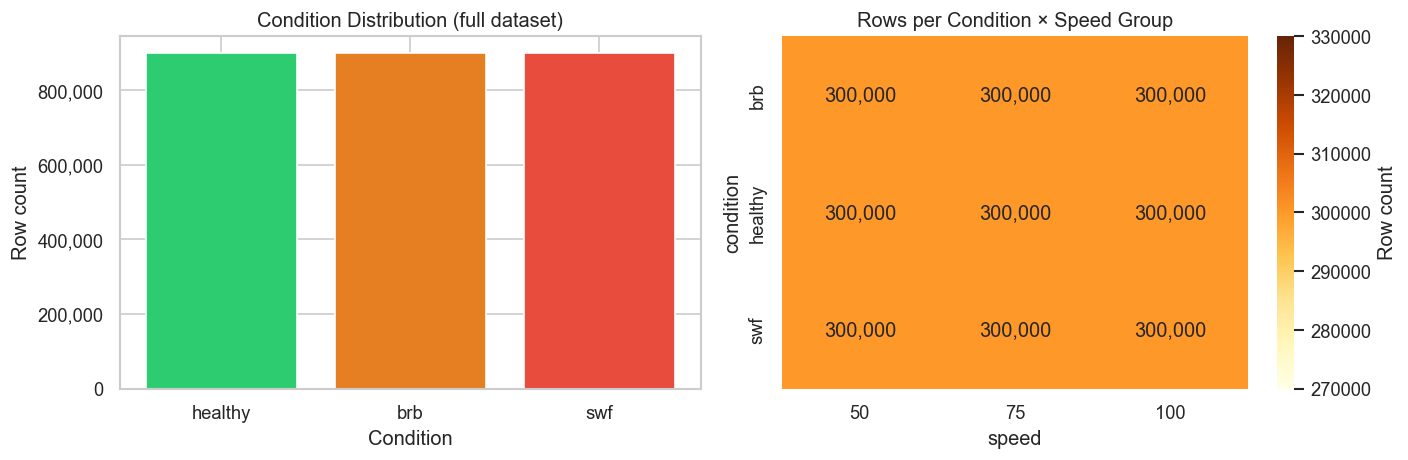

In [42]:
# Target class distribution — bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Condition counts
condition_counts = df['condition'].value_counts().reindex(CONDITION_ORDER)
axes[0].bar(condition_counts.index, condition_counts.values,
            color=[PALETTE[c] for c in condition_counts.index], edgecolor='white')
axes[0].set_title('Condition Distribution (full dataset)')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Row count')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Condition × speed heatmap
group_matrix = df.groupby(['condition','speed']).size().unstack()
sns.heatmap(group_matrix, annot=True, fmt=',', cmap='YlOrBr', ax=axes[1],
            cbar_kws={'label': 'Row count'})
axes[1].set_title('Rows per Condition × Speed Group')

plt.tight_layout()
plt.show()

### Target Distribution Summary

Both visualisations confirm the perfectly balanced design of the dataset. The bar chart shows all three conditions — healthy, brb, swf — at exactly 900,000 rows each, with no visible skew toward any single class. The heatmap breaks this down further across the 9 condition × speed combinations, with every cell showing exactly 300,000 rows.

This balance means no class-weighting, oversampling, or undersampling will be needed when models are trained later — the dataset is already structured to give equal representation to every fault condition at every operating speed.

## 2. Sample Waveforms per Condition

Visualise 1,024 consecutive samples (one window) of Phase A, measurement m1, at 100% speed for each condition. This gives a baseline visual impression of whether fault conditions alter the raw time-domain waveform shape.

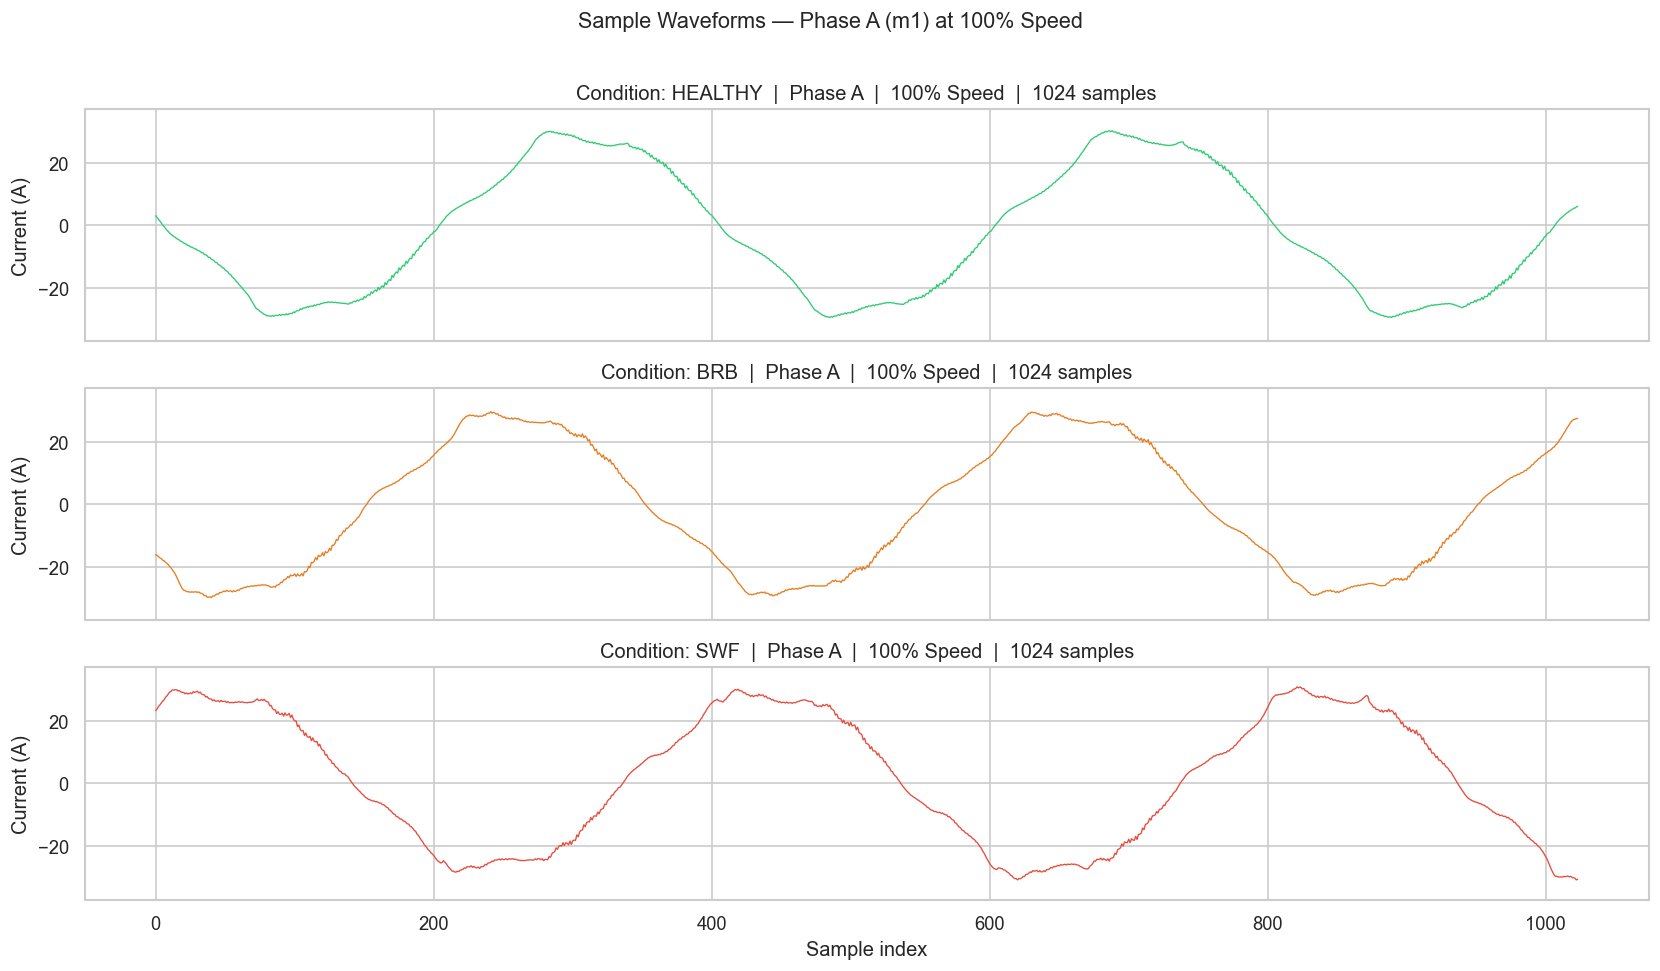

In [43]:
# Waveform visualisation — Phase A, m1, 100% speed, one window per condition
actual_max = df[SIGNAL_COLS].abs().max().max()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, cond in zip(axes, CONDITION_ORDER):
    window = (
        df[(df['condition'] == cond) & (df['speed'] == 100)]
        ['A_m1']
        .iloc[:WINDOW_SIZE]
        .values
    )
    ax.plot(window, color=PALETTE[cond], linewidth=0.8)
    ax.set_title(f'Condition: {cond.upper()}  |  Phase A  |  100% Speed  |  {WINDOW_SIZE} samples')
    ax.set_ylabel('Current (A)')
    ax.set_ylim(-actual_max * 1.1, actual_max * 1.1)

axes[-1].set_xlabel('Sample index')
plt.suptitle('Sample Waveforms — Phase A (m1) at 100% Speed', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Sample Waveforms Summary

All three conditions show the same fundamental sine wave shape, amplitude range (roughly ±34A), and cycle period — visually, healthy, BRB, and SWF current waveforms are nearly indistinguishable to the naked eye. None of the conditions shows an obvious distortion, spike, or amplitude shift that a simple visual threshold rule could catch.

This is the expected and important result. If fault conditions were visible directly in the time-domain waveform, no machine learning or signature analysis would be necessary — a basic visual or threshold check would suffice. The fact that all three conditions look alike at this scale supports the project's central hypothesis: fault signatures are subtle, frequency-domain phenomena (sidebands and harmonics) that are not visible in raw time-domain inspection, reinforcing the need for FFT-based feature extraction before classification.

## 3. Amplitude Distributions per Condition

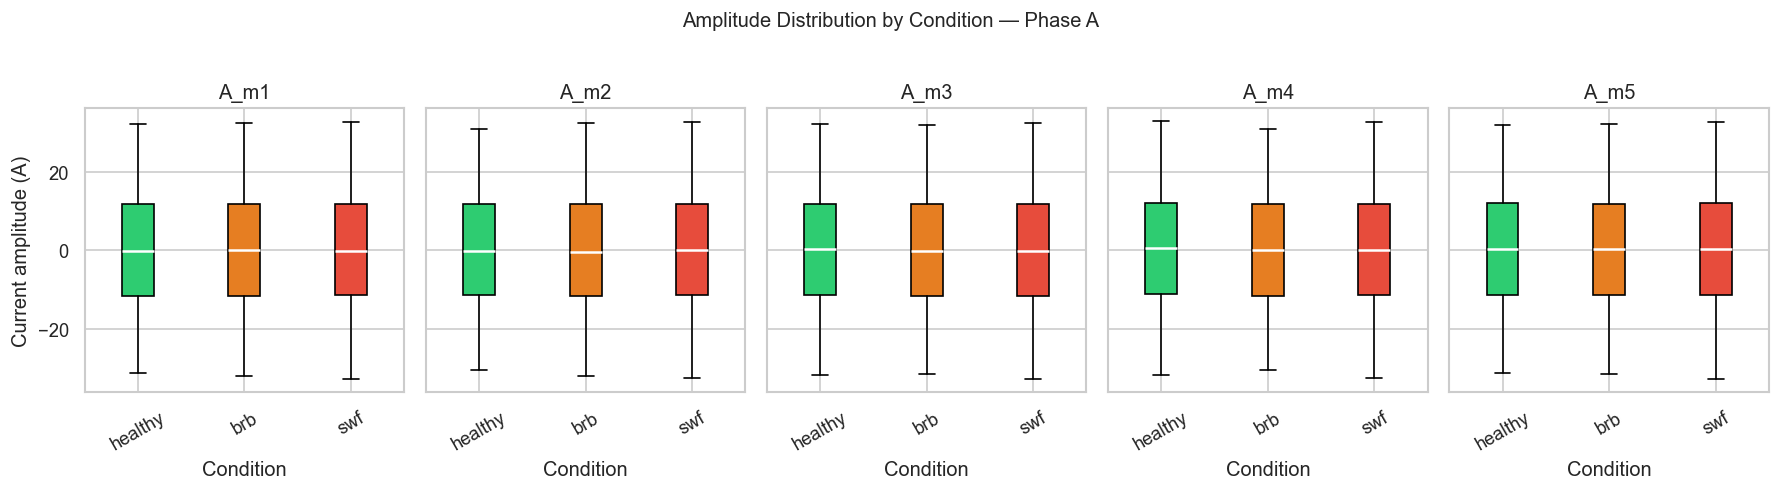

In [44]:
# Box plots of Phase A columns by condition (representative phase)
phase_a_cols = [c for c in SIGNAL_COLS if c.startswith('A_')]

fig, axes = plt.subplots(1, len(phase_a_cols), figsize=(15, 4), sharey=True)

for ax, col in zip(axes, phase_a_cols):
    data_by_cond = [df_sample[df_sample['condition'] == c][col].values
                    for c in CONDITION_ORDER]
    bp = ax.boxplot(data_by_cond, tick_labels=CONDITION_ORDER, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 1.5})
    for patch, cond in zip(bp['boxes'], CONDITION_ORDER):
        patch.set_facecolor(PALETTE[cond])
    ax.set_title(col)
    ax.set_xlabel('Condition')
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Current amplitude (A)')
plt.suptitle('Amplitude Distribution by Condition — Phase A', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Amplitude Distributions Summary

Across all five measurement replicates (A_m1–A_m5), the box plots show essentially identical distributions for healthy, BRB, and SWF conditions: same median (~0A), same interquartile range (±12A), and same whisker extent (±34A). No condition shows a visibly wider spread, shifted median, or different shape than the others.

This confirms, at the distribution level, what the waveform plots already suggested: raw amplitude statistics do not separate fault conditions. Combined with the consistent shape across all five replicates, this also reinforces that m1–m5 behave as reliable, repeatable experimental runs rather than introducing extra variability. The result strengthens the case that any useful classification signal must come from feature extraction beyond simple amplitude distribution .

## 4. RMS and Kurtosis by Condition and Speed

RMS and kurtosis are the two most diagnostically relevant time-domain statistics for MCSA fault detection. RMS captures signal energy; kurtosis is sensitive to impulsive fault events.

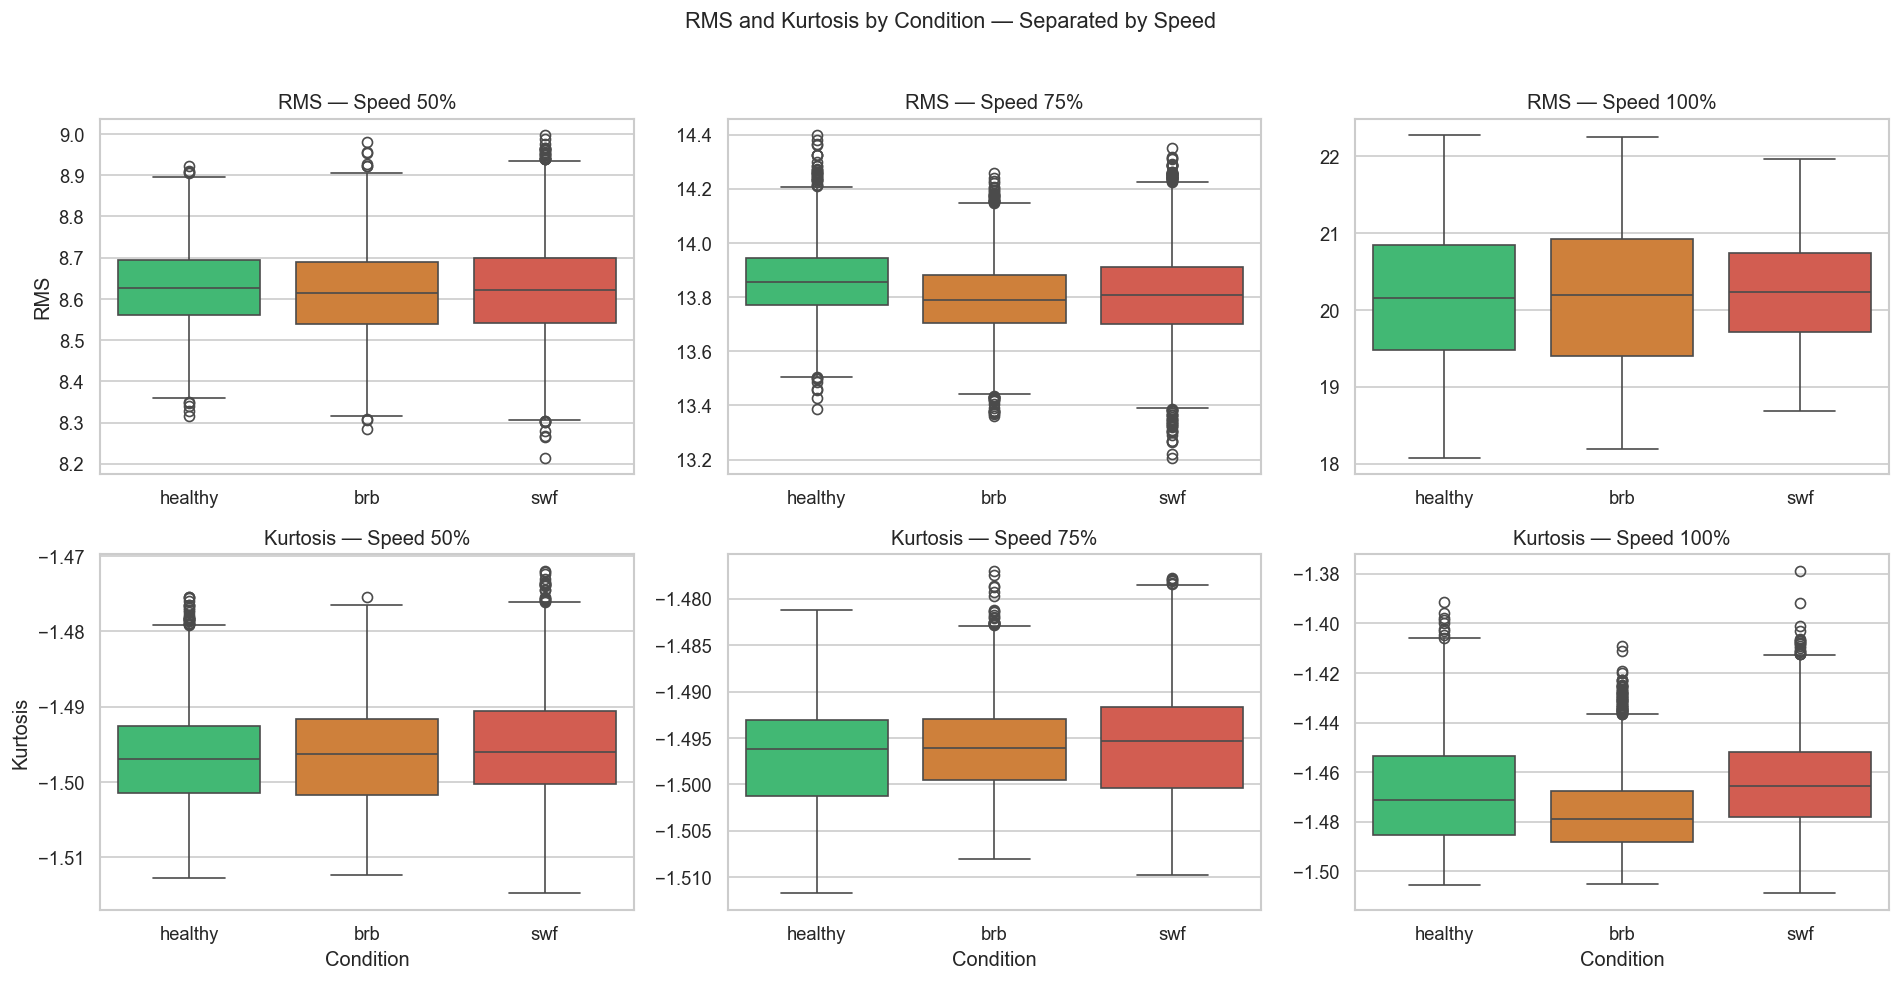

In [45]:
# RMS and Kurtosis by Condition, split by Speed (separate y-scale per speed)
df_sample['rms']      = np.sqrt((df_sample[SIGNAL_COLS] ** 2).mean(axis=1))
df_sample['kurtosis'] = df_sample[SIGNAL_COLS].apply(stats.kurtosis, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col_idx, spd in enumerate(SPEED_ORDER):
    data = df_sample[df_sample['speed'] == spd]

    # RMS (top row)
    ax_rms = axes[0, col_idx]
    sns.boxplot(data=data, x='condition', y='rms', order=CONDITION_ORDER,
            hue='condition', palette=PALETTE, legend=False, ax=ax_rms)
    ax_rms.set_title(f'RMS — Speed {spd}%')
    ax_rms.set_xlabel('')
    ax_rms.set_ylabel('RMS' if col_idx == 0 else '')

    # Kurtosis (bottom row)
    ax_kurt = axes[1, col_idx]
    sns.boxplot(data=data, x='condition', y='kurtosis', order=CONDITION_ORDER,
            hue='condition', palette=PALETTE, legend=False, ax=ax_kurt)
    ax_kurt.set_title(f'Kurtosis — Speed {spd}%')
    ax_kurt.set_xlabel('Condition')
    ax_kurt.set_ylabel('Kurtosis' if col_idx == 0 else '')

plt.suptitle('RMS and Kurtosis by Condition — Separated by Speed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### RMS and Kurtosis Summary

We computed RMS and kurtosis per row and compared the three conditions.

RMS shows almost no separation between healthy, BRB, and SWF at any speed — the boxes overlap nearly completely. Kurtosis is mostly the same story, except at 100% speed, where BRB sits slightly lower than healthy and SWF. The difference is real but small, and the boxes still overlap significantly.

**Conclusion:** RMS does not help distinguish fault conditions. Kurtosis carries a weak signal only at higher speed, but neither metric is strong enough to classify faults on its own. This supports the case for frequency-domain feature extraction in the next phase.

## 5. Inter-Measurement Consistency (m1–m5)

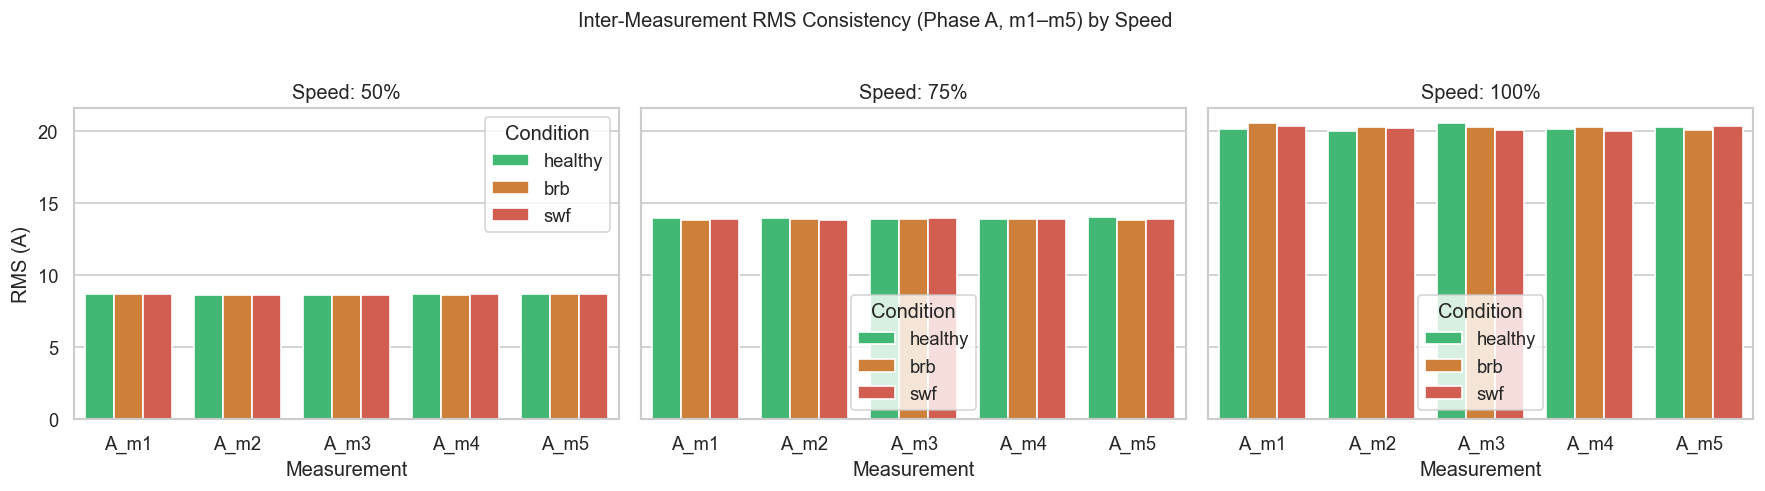

speed                     50       75         100
condition measurement                            
brb       A_m1         8.6666  13.8280  20.571301
          A_m2         8.6301  13.9032  20.264000
          A_m3         8.6120  13.9138  20.295300
          A_m4         8.6485  13.9189  20.238100
          A_m5         8.6806  13.7907  20.062300
healthy   A_m1         8.6810  13.9501  20.149900
          A_m2         8.6388  13.9824  19.984900
          A_m3         8.6202  13.8899  20.536400
          A_m4         8.6602  13.9209  20.142300
          A_m5         8.6763  13.9979  20.261700
swf       A_m1         8.6694  13.8564  20.335699
          A_m2         8.6373  13.8388  20.222200
          A_m3         8.6337  13.9586  20.034100
          A_m4         8.6523  13.9023  19.996201
          A_m5         8.6779  13.8716  20.319300


In [46]:
# Inter-measurement consistency — compare RMS of m1–m5 per condition × speed
phase_a_cols = [f'A_m{i}' for i in range(1, 6)]

rms_rows = []
for (cond, spd), grp in df_sample.groupby(['condition', 'speed']):
    for col in phase_a_cols:
        rms_val = np.sqrt((grp[col] ** 2).mean())
        rms_rows.append({'condition': cond, 'speed': spd, 'measurement': col, 'rms': rms_val})

rms_df = pd.DataFrame(rms_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, spd in zip(axes, SPEED_ORDER):
    data = rms_df[rms_df['speed'] == spd]
    sns.barplot(data=data, x='measurement', y='rms', hue='condition',
                hue_order=CONDITION_ORDER, palette=PALETTE, ax=ax)
    ax.set_title(f'Speed: {spd}%')
    ax.set_xlabel('Measurement')
    ax.set_ylabel('RMS (A)' if spd == 50 else '')
    ax.legend(title='Condition')

plt.suptitle('Inter-Measurement RMS Consistency (Phase A, m1–m5) by Speed', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(rms_df.pivot_table(index=['condition', 'measurement'], columns='speed', values='rms').round(4))

### Inter-Measurement Consistency Summary

We checked whether the five measurement replicates (m1–m5) behave consistently with each other, since each represents an independent experimental run rather than a separate sensor. RMS was computed per measurement, per condition, per speed, and plotted side by side to compare m1 through m5 within each group.

At every speed, the five bars for each condition sit at nearly the same height — the spread between m1 and m5 is under 0.07A for 50% speed, and proportionally just as tight at 75% and 100%. This holds true across all three conditions.

**Conclusion:** The five measurement replicates are highly consistent and reproducible. This confirms they can be treated as independent, reliable training samples rather than a source of noise, which is good news for the modeling phase — it effectively gives more usable data per condition without compromising data quality.

## 6. Correlation Analysis

### 6a. Signal–Signal Correlation Matrix

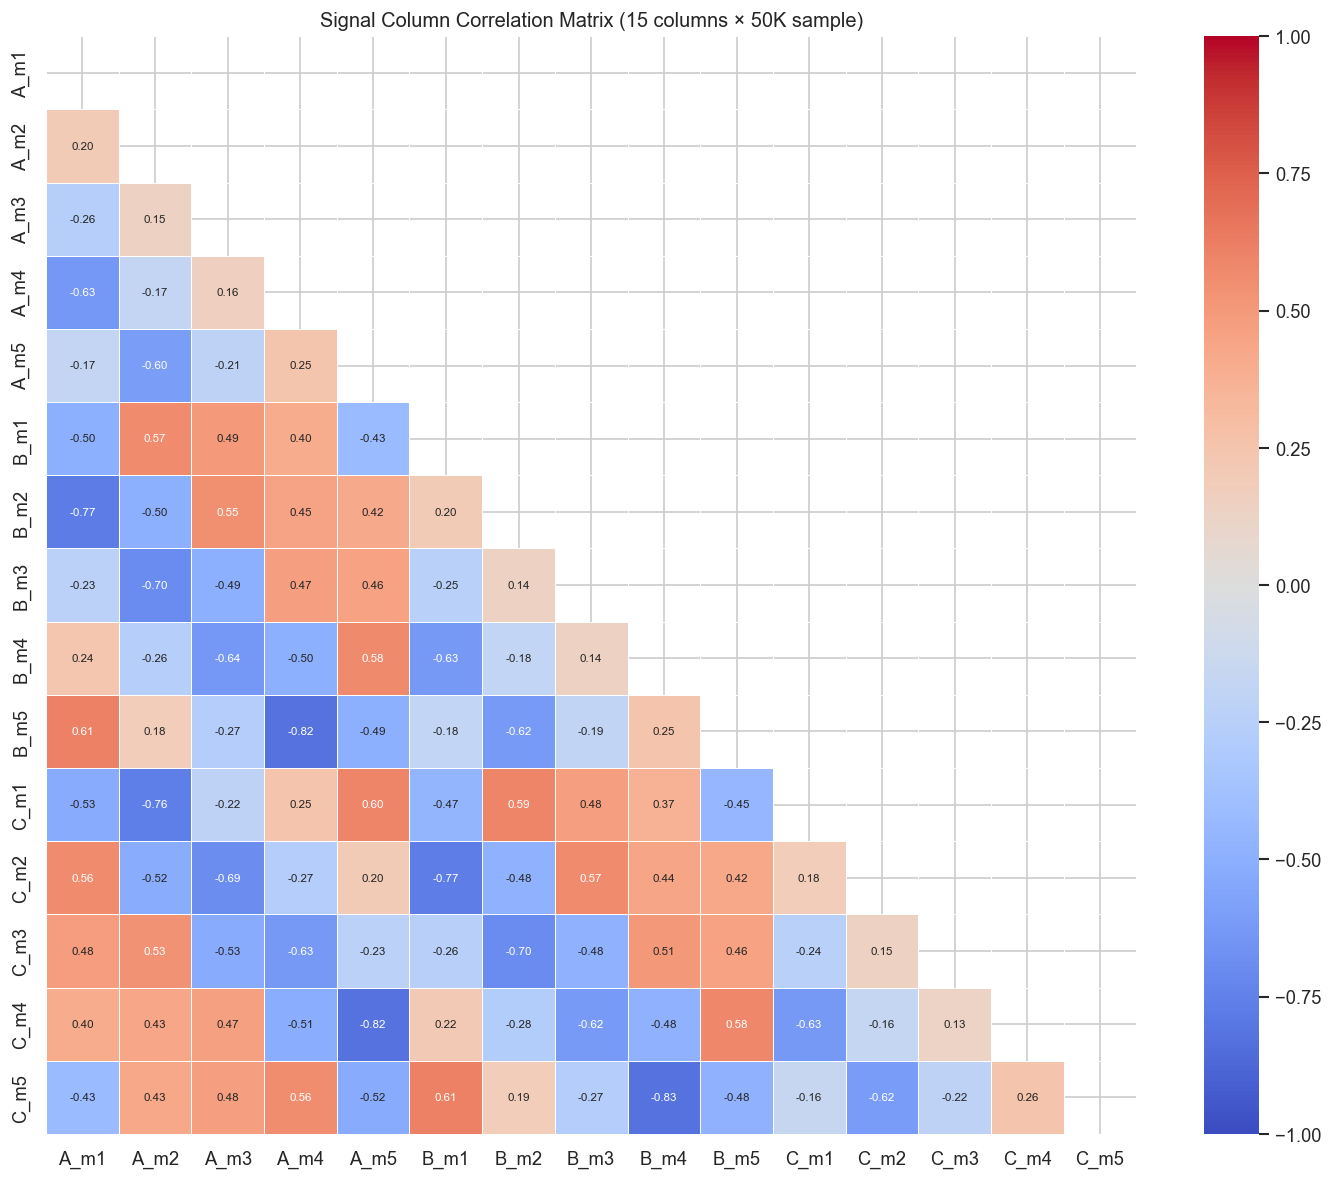

In [47]:
corr_matrix = df_sample[SIGNAL_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Signal Column Correlation Matrix (15 columns × 50K sample)')
plt.tight_layout()
plt.show()

### Signal–Signal Correlation Summary

We computed Pearson correlation between all 15 signal columns to check for redundancy. The five replicates within the same phase (A_m1–A_m5) do not correlate strongly with each other, confirming they capture independent variation rather than duplicating the same signal. Cross-phase correlations are moderate (-0.82 to +0.61), which is expected given the 120° phase shift in a three-phase system. No column pair is near-perfectly correlated.

**Conclusion:** All 15 signal columns carry distinct information and can be retained for feature extraction without major redundancy concerns.

### 6b. Signal Amplitude Correlation with Condition Label

Encodes the condition label as an ordinal integer (healthy=0, brb=1, swf=2) and computes Pearson correlation against each signal column. This quantifies whether raw amplitude carries any linear discriminative information about fault condition.

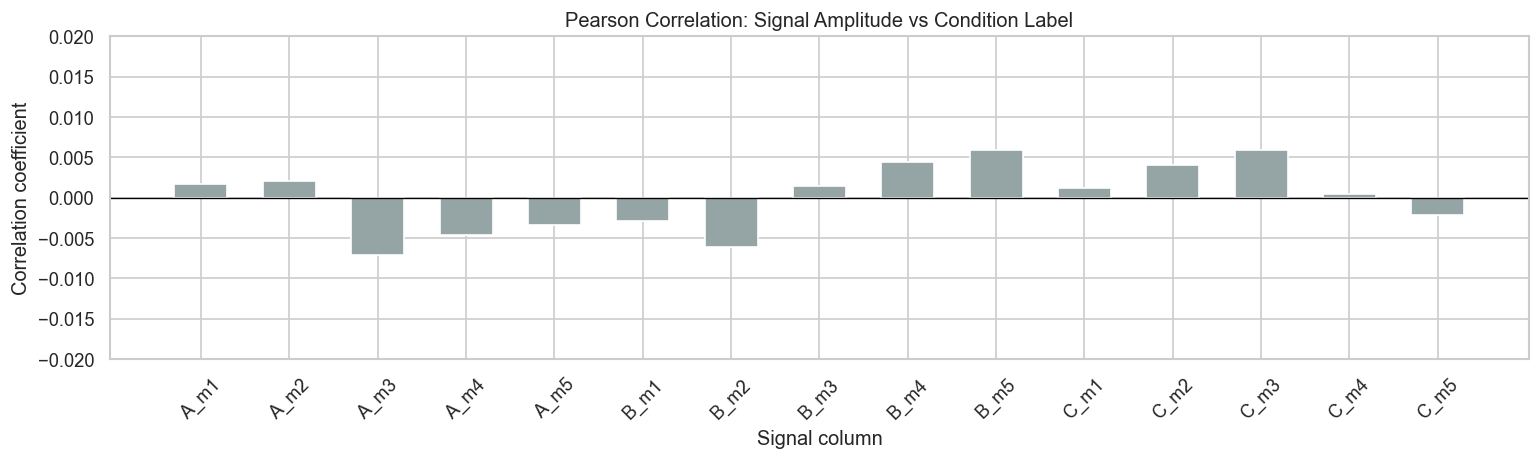

Max absolute correlation with condition: 0.0071
A_m1    0.0017
A_m2    0.0021
A_m3   -0.0071
A_m4   -0.0046
A_m5   -0.0034
B_m1   -0.0029
B_m2   -0.0062
B_m3    0.0014
B_m4    0.0044
B_m5    0.0059
C_m1    0.0011
C_m2    0.0041
C_m3    0.0059
C_m4    0.0004
C_m5   -0.0022
Name: condition_encoded, dtype: float64


In [48]:
condition_map = {'healthy': 0, 'brb': 1, 'swf': 2}
df_sample['condition_encoded'] = df_sample['condition'].map(condition_map)

condition_corr = (df_sample[SIGNAL_COLS + ['condition_encoded']]
                  .corr()['condition_encoded']
                  .drop('condition_encoded'))

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#e74c3c' if abs(v) > 0.05 else '#95a5a6' for v in condition_corr.values]
ax.bar(condition_corr.index, condition_corr.values, color=colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation: Signal Amplitude vs Condition Label')
ax.set_xlabel('Signal column')
ax.set_ylabel('Correlation coefficient')
ax.set_ylim(-0.02, 0.02)  # zoomed in to actual data range
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Max absolute correlation with condition: {condition_corr.abs().max():.4f}')
print(condition_corr.round(4))

### Signal Amplitude vs Condition Correlation Summary

We encoded condition as an integer (healthy=0, brb=1, swf=2) and computed Pearson correlation against each signal column. Every column came back between -0.0071 and 0.0059 — effectively zero, with no column standing out.

**Conclusion:** Raw signal amplitude carries no usable information about fault condition. This confirms FFT-based feature extraction is required before any classifier can distinguish healthy, BRB, and SWF.

### EDA Insight — Frequency Domain Justification

> **Finding:** Maximum Pearson correlation between raw signal amplitude and the condition label is ≈ 0.007 — effectively zero across all 15 signal columns.
>
> **Interpretation:** Raw time-domain amplitude contains no linear discriminative information about motor fault condition. This is the expected result in MCSA: fault signatures (BRB sidebands at `f ± 2sf`, SWF harmonics at `3f`, `5f`) manifest almost exclusively in the **frequency domain**. This finding directly validates the need for FFT-based feature extraction prior to ML classification, and is consistent with results reported in the original senior thesis rule-based system.
>
> **Implication for modeling:** Any model trained directly on raw signal amplitude columns will perform at chance level. Feature extraction (FFT, wavelet, or time-domain statistics on windowed segments) is a prerequisite, not an option.

## EDA Summary

| Finding | Implication |
|---------|-------------|
| Dataset is perfectly balanced (900K rows per condition) | No class-weighting or resampling required |
| All 9 condition × speed groups have exactly 300,000 rows | Clean experimental design; no leakage risk from group imbalance |
| Raw amplitude correlation with condition ≈ 0.007 (max) | Fault signatures are frequency-domain phenomena; FFT extraction is mandatory before ML |
| RMS shows no separation between conditions at any speed | RMS alone will not contribute meaningfully to a time-domain feature pipeline |
| Kurtosis shows a weak, speed-dependent separation (notably at 100% speed) | May offer minor discriminative value as a secondary time-domain feature, but not sufficient alone |
| m1–m5 inter-measurement RMS is highly consistent within each group | Measurement replicates are reliable; all five can be used as independent training samples |
| Speed strongly affects RMS magnitude across all conditions | Speed must be included as a feature or used for stratified modeling |
| All 15 signal columns are weakly inter-correlated, no major redundancy | All columns can be retained going into feature extraction |

# Data Preprocessing & Feature Engineering

**Outline only — not executed in this notebook.**

### Step 1 — Recording-Level Train/Test Split (Leakage Prevention)

The split must occur at the **recording level**, before any windowing takes place. Each recording is one continuous experimental run under a fixed condition and speed. If we windowed first and then split, adjacent windows from the same recording — which overlap by 50% and share most of their samples — could land on opposite sides of the train/test boundary. The model would then be tested on data that is nearly identical to something it trained on, inflating performance metrics in a way that would not hold up on genuinely unseen motors.

Proposed split: 80% train / 20% test, stratified by `condition` and `speed`, performed on whole recordings before segmentation.

### Step 2 — Sliding Window Segmentation

Each recording is split into overlapping 1,024-sample windows, stepping forward by 512 samples (50% overlap) each time, as shown below.

<img src="./img/sliding_window_overlap.png" width="700">

The overlap matters because fault events don't always align neatly with window boundaries:

<img src="./img/why_overlap_matters.png" width="700">

The overlap means a fault event near a window boundary still ends up fully inside at least one window, instead of being cut in half and weakened in both.

Applying this across all recordings produces approximately **26,000 labeled samples**, each a 1024-point current segment tagged with its `condition` and `speed`..

### Step 3 — Feature Extraction Pipelines

Four parallel feature pipelines will be built and compared:

| Pipeline | Features extracted per window |
|----------|------------------------------|
| **TD** — Time-Domain | RMS, STD, peak, kurtosis, skewness, crest factor — per phase (3 phases × 6 = 18 features) |
| **FFT** — Frequency-Domain | Sideband energy ratios at `f ± 2sf`, harmonic amplitudes at `3f`, `5f`, `7f` — per phase (computed on the full recording, not the window, to preserve frequency resolution) |
| **WT** — Wavelet | Energy and entropy per decomposition scale from CWT — per phase |
| **HYB** — Hybrid | Concatenation of TD + FFT + WT feature vectors |

### Step 4 — Encoding and Scaling

- `condition` label-encoded as integer (healthy=0, brb=1, swf=2) for classifier input
- `speed` included as an additional feature (ordinal: 50/75/100)
- StandardScaler applied to all numerical features, fit on the training set only to avoid leaking test-set statistics into the scaling

# Modelling Approach

**Outline only — not executed in this notebook.**

### Task Type
Multi-class classification (3 classes: healthy / brb / swf)

### Models Planned

Three classifiers will be trained on each of the four feature pipelines, giving **12 models in total**:

| # | Model | Purpose |
|---|-------|---------|
| 1 | **Dummy Classifier** (stratified) | Baseline — confirms models beat random guessing |
| 2 | **Random Forest** | A strong general-purpose classifier that works well with engineered features |
| 3 | **SVM** (RBF kernel) | Performs well when there are many features and clear class boundaries |

The full comparison structure across all pipelines:

| Pipeline | Dummy | Random Forest | SVM |
|----------|-------|---------------|-----|
| TD — Time-Domain | ✓ | ✓ | ✓ |
| FFT — Frequency-Domain | ✓ | ✓ | ✓ |
| WT — Wavelet | ✓ | ✓ | ✓ |
| HYB — Hybrid | ✓ | ✓ | ✓ |

### Evaluation Metrics

- **Weighted F1-score** — primary metric; balances precision and recall across all three classes
- **Per-class precision and recall** — catches cases where one fault type is consistently missed or misclassified
- **Confusion matrix** — visual breakdown of which conditions are being confused with each other
- **ROC-AUC (one-vs-rest)** — measures how well each class is separated from the others; secondary metric

### Baseline Comparison

All models will be benchmarked against the **rule-based MCSA system** from the senior thesis (Bahrain Polytechnic, 2024), which uses FFT sideband ratio and harmonic ratio thresholds to classify BRB and SWF. This comparison is the core research contribution — determining whether a data-driven ML approach adds real value over the existing engineering rule-based system.

### Success Threshold

- Weighted F1-score ≥ **0.90** on the held-out test set
- Per-class recall ≥ **0.85** for both BRB and SWF to minimise missed fault detections

> **Note:** The above represents the ideal modeling plan. The number of pipelines or classifiers may be adjusted depending on time available before the final capstone submission.